In [31]:
import matplotlib.pyplot as plt
import numpy as np
from monodromy.render import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
import scienceplots
import lovelyplots
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass
from gulps.utils.invariants import GateInvariants
from gulps.utils.isa import expected_costs
from gulps.utils.logging_config import logger
from gulps.utils.visualize import render_path
import itertools

In [ ]:
def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()


phi = np.pi / 6
full_isa = [
    (fsim(np.pi / 2, phi).power(1.0), 1.0, "1"),
    (fsim(np.pi / 2, phi).power(1 / 2), 1 / 2, "2"),
    (fsim(np.pi / 2, phi).power(1 / 3), 1 / 3, "3"),
    (fsim(np.pi / 2, phi).power(1 / 4), 1 / 4, "4"),
    (fsim(np.pi / 2, phi).power(1 / 5), 1 / 5, "5"),
    (fsim(np.pi / 2, phi).power(1 / 6), 1 / 6, "6"),
    (fsim(np.pi / 2, phi).power(1 / 7), 1 / 7, "7"),
    (fsim(np.pi / 2, phi).power(1 / 8), 1 / 8, "8"),
    # (fsim(np.pi / 2, phi).power(1 / 9), 1 / 9, "9"),
    # (fsim(np.pi / 2, phi).power(1 / 10), 1 / 10, "10"),
    # (fsim(np.pi / 2, phi).power(1 / 11), 1 / 11, "11"),
    # (fsim(np.pi / 2, phi).power(1 / 12), 1 / 12, "12"),
]
gate_set, costs, names = zip(*full_isa)
decomposer = GulpsDecomposer(
    gate_set=gate_set, costs=costs, names=names, precompute_polytopes=False
)
u_gi = GateInvariants.from_unitary(iSwapGate())

In [33]:
results = []  # (used_gate_count, cost, label)

# instead of creating separate decomposers, enumerate manually.
# this should be much faster, skips recomputing identical sentences.
for sentence in tqdm(decomposer.isa.enumerate()):
    # heuristic filter to skip a full LP for obvious non-starters
    if sum(gate.strength for gate in sentence) < u_gi.strength:
        continue

    sentence_out = decomposer._try_lp(sentence, u_gi)[0]

    if sentence_out is None:
        continue

    # save it in results
    # Actual number of unique gates used in the decomposition
    used_gate_count = len(set(sentence_out))
    names = [g.name for g in sentence_out]

    # Compute cost
    iswap_cost = sum(decomposer.isa.cost_dict[g] for g in sentence_out)

    # Label with denominators only
    label = "{" + ",".join(names) + "}"
    results.append((used_gate_count, float(iswap_cost), label))

    # if sentence_out is [fsim, fsim, fsim]:
    if iswap_cost == 1.5:
        break

# Sort by used-gate count then cost
results.sort(key=lambda r: (r[0], r[1]))

0it [00:00, ?it/s]

2732it [00:05, 525.04it/s]


In [34]:
from gulps.cts_linear_program import ContinuousISAConstraints

base = GateInvariants.from_unitary(fsim(np.pi / 2, phi).power(1.0))
solver = ContinuousISAConstraints(base=base, sequence_length=8, offset=1e-6)
target = GateInvariants.from_unitary(iSwapGate())
solver.set_target(target, rho_bool=False)

gi_list, intermediates, ks = solver.solve(log_output=False)
print(ks, sum(ks))
optimal_cost = sum(ks)

[0.9142857142857144, 0.11428571428571432, 0.11428571428571432] 1.142857142857143


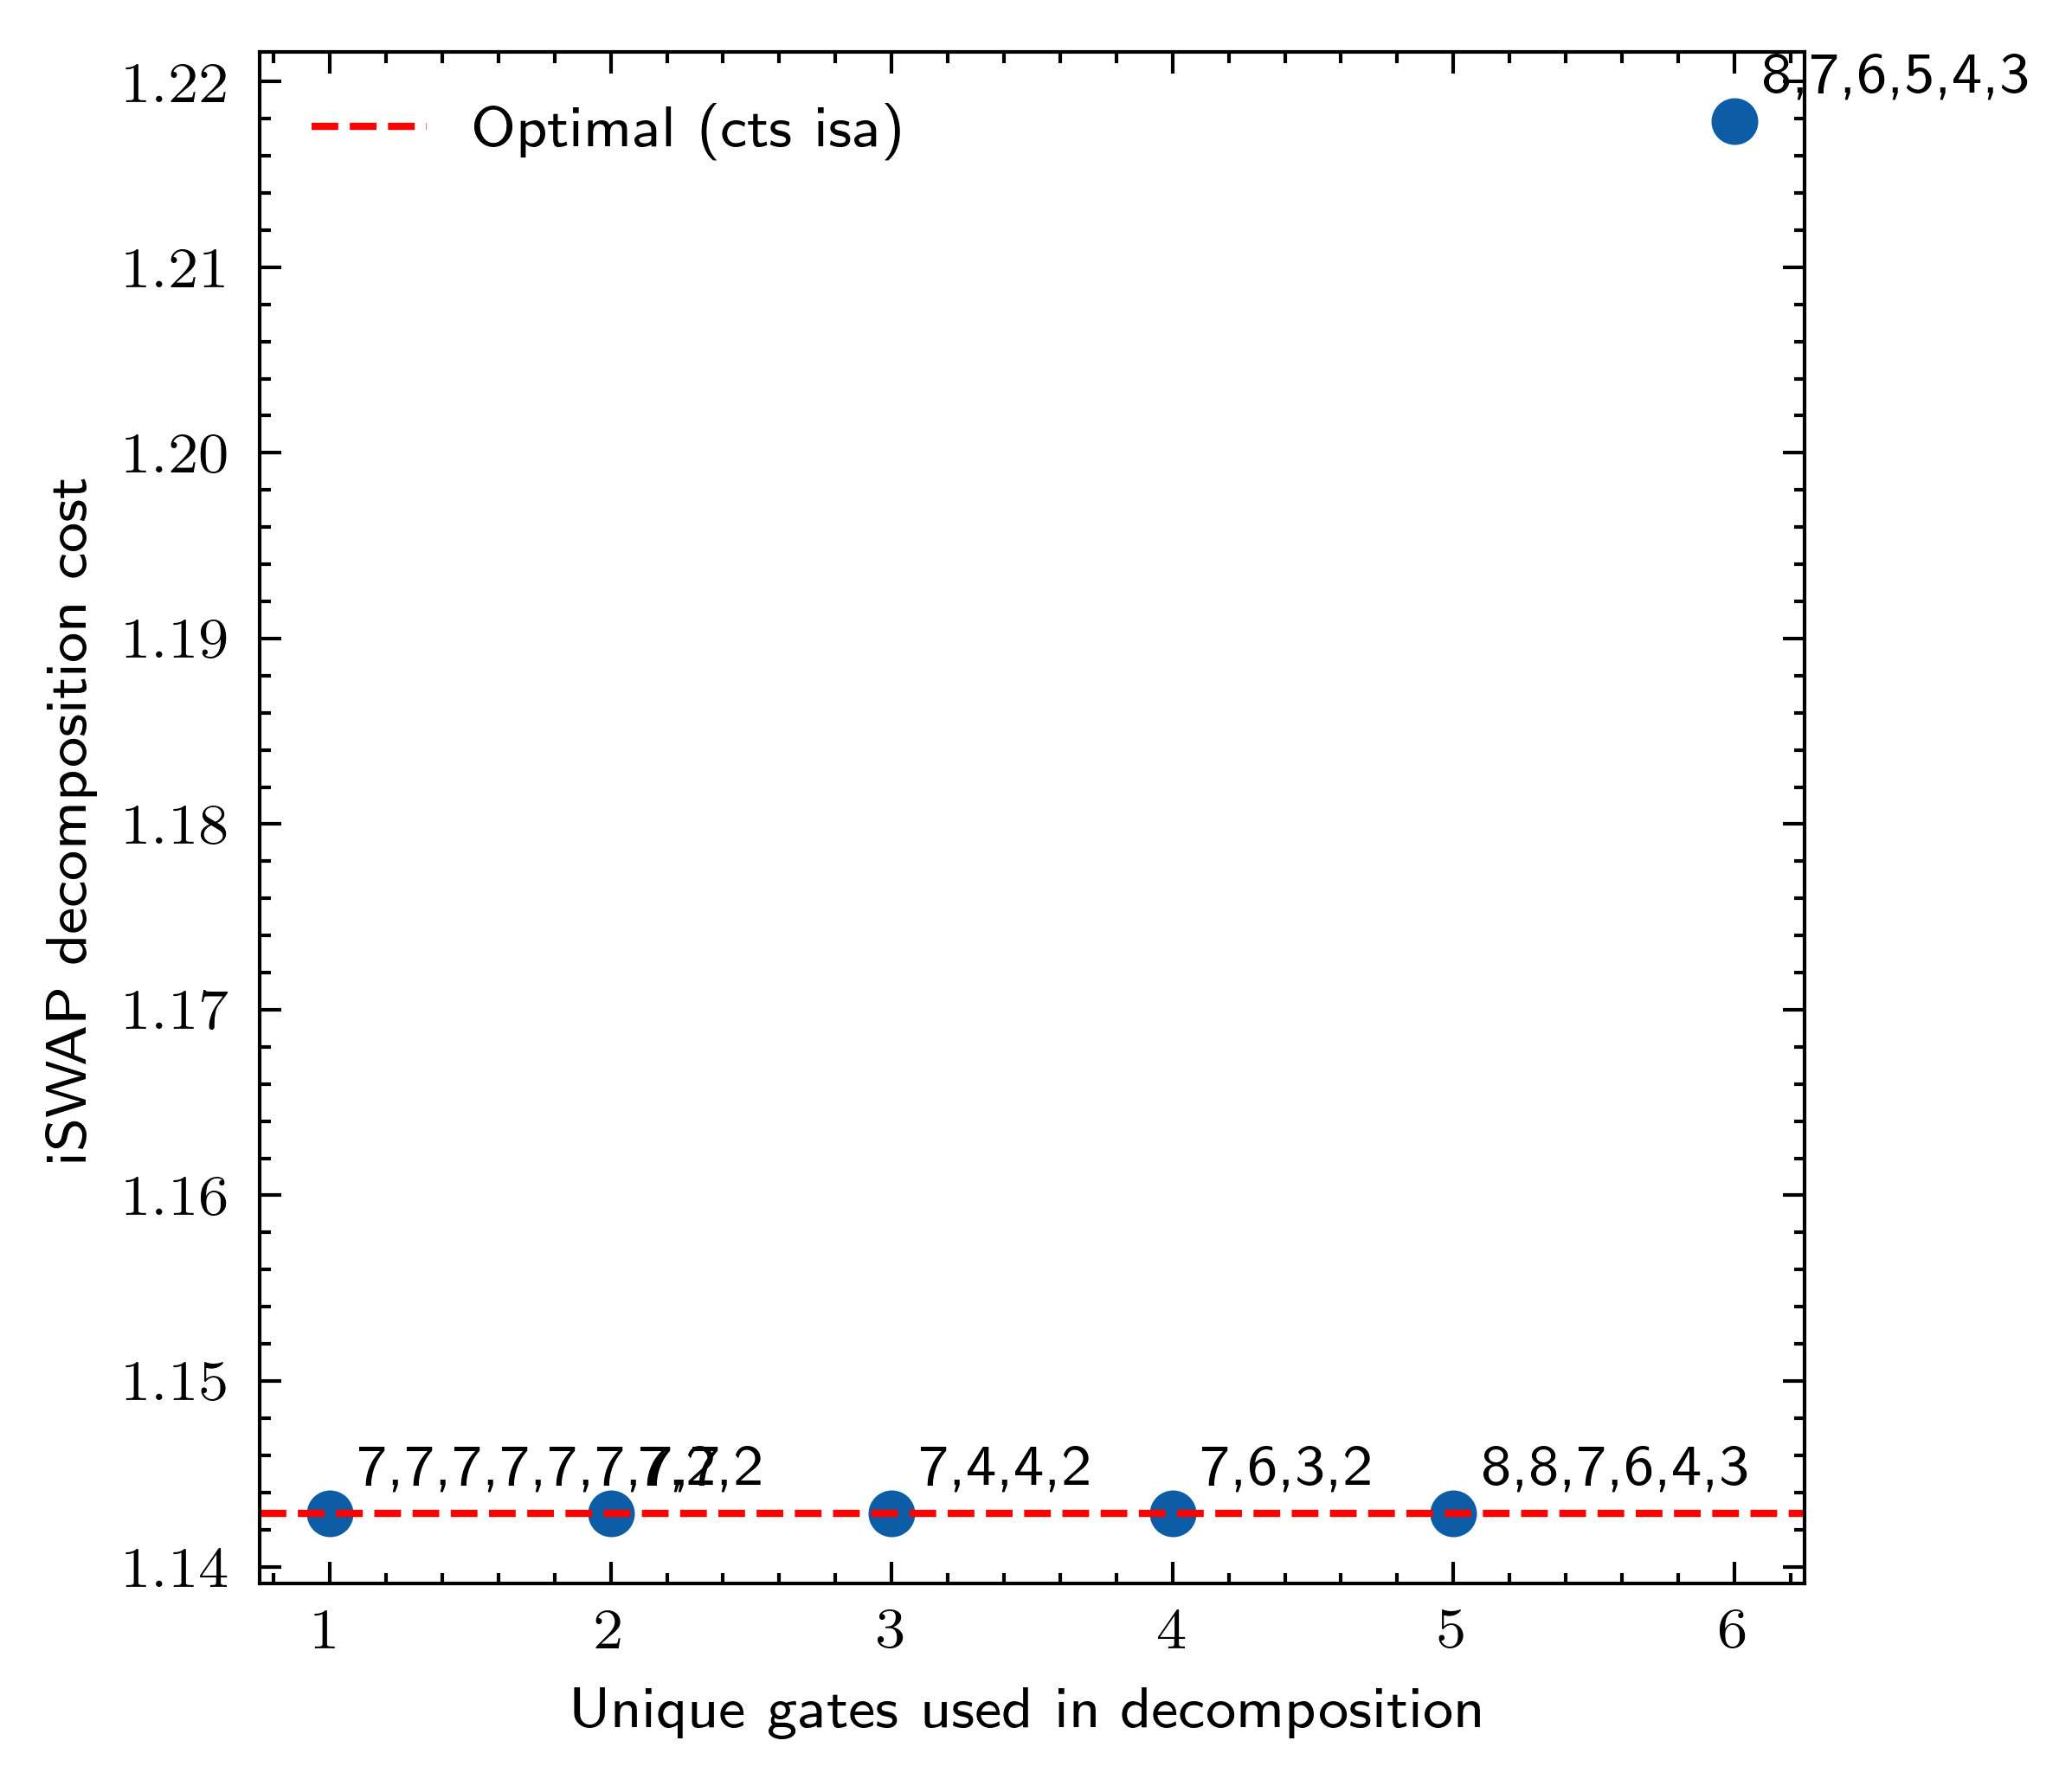

In [35]:
from collections import defaultdict

xs_all = [count for count, _, _ in results]  # jitter
ys_all = [cost for _, cost, _ in results]

# Group results by used_gate_count, keep only min-cost entry
best_by_count = {}
for count, cost, label in results:
    if count not in best_by_count or cost < best_by_count[count][0]:
        best_by_count[count] = (cost, label)

# Sort by x-axis value
best_items = sorted(best_by_count.items())

# Extract for plotting
xs_min = [count for count, _ in best_items]
ys_min = [cost for _, (cost, _) in best_items]
labels_min = [label for _, (_, label) in best_items]

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axs = plt.subplots(1, 1, figsize=(4, 3.5), sharey=True)

    # --- Left: all results ---
    # axs = axs[0]
    # axs.scatter(xs_all, ys_all, s=30)
    # axs.set_xlabel("Unique gates used in decomposition")
    axs.set_ylabel("iSWAP decomposition cost")
    # axs.set_title("All subsets")

    # --- Right: min-cost per used_gate_count ---
    axs = axs  # [1]
    axs.scatter(xs_min, ys_min, s=30)
    axs.set_xlabel("Unique gates used in decomposition")
    # axs.set_title("Min cost per x-axis value")
    for x, y, label in zip(xs_min, ys_min, labels_min):
        axs.annotate(
            label, (x, y), textcoords="offset points", xytext=(4, 4), fontsize=8
        )

    # plot optimal as dashed line
    axs.axhline(optimal_cost, color="red", linestyle="--", label="Optimal (cts isa)")
    axs.legend()

    fig.tight_layout()

plt.show()


In [ ]:
# plot optimal iSWAP cost as a function of phi
def optimal_cost(phi):
    base = GateInvariants.from_unitary(fsim(np.pi / 2, phi).power(1.0))
    solver = ContinuousISAConstraints(base=base, sequence_length=8, offset=1e-6)
    target = GateInvariants.from_unitary(iSwapGate())
    solver.set_target(target, rho_bool=False)

    gi_list, intermediates, ks = solver.solve(log_output=False)
    optimal_cost = sum(ks)
    return optimal_cost


# sweep phi from 0 to np.pi
phi_values = np.linspace(0, np.pi, 100)
optimal_costs = [optimal_cost(phi) for phi in phi_values]

In [ ]:
phi = np.pi / 6
full_isa = [
    (fsim(np.pi / 2, phi).power(1.0), 1.0, "1"),
]
gate_set, costs, names = zip(*full_isa)
decomposer = GulpsDecomposer(
    gate_set=gate_set, costs=costs, names=names, precompute_polytopes=False
)
u_gi = GateInvariants.from_unitary(iSwapGate())

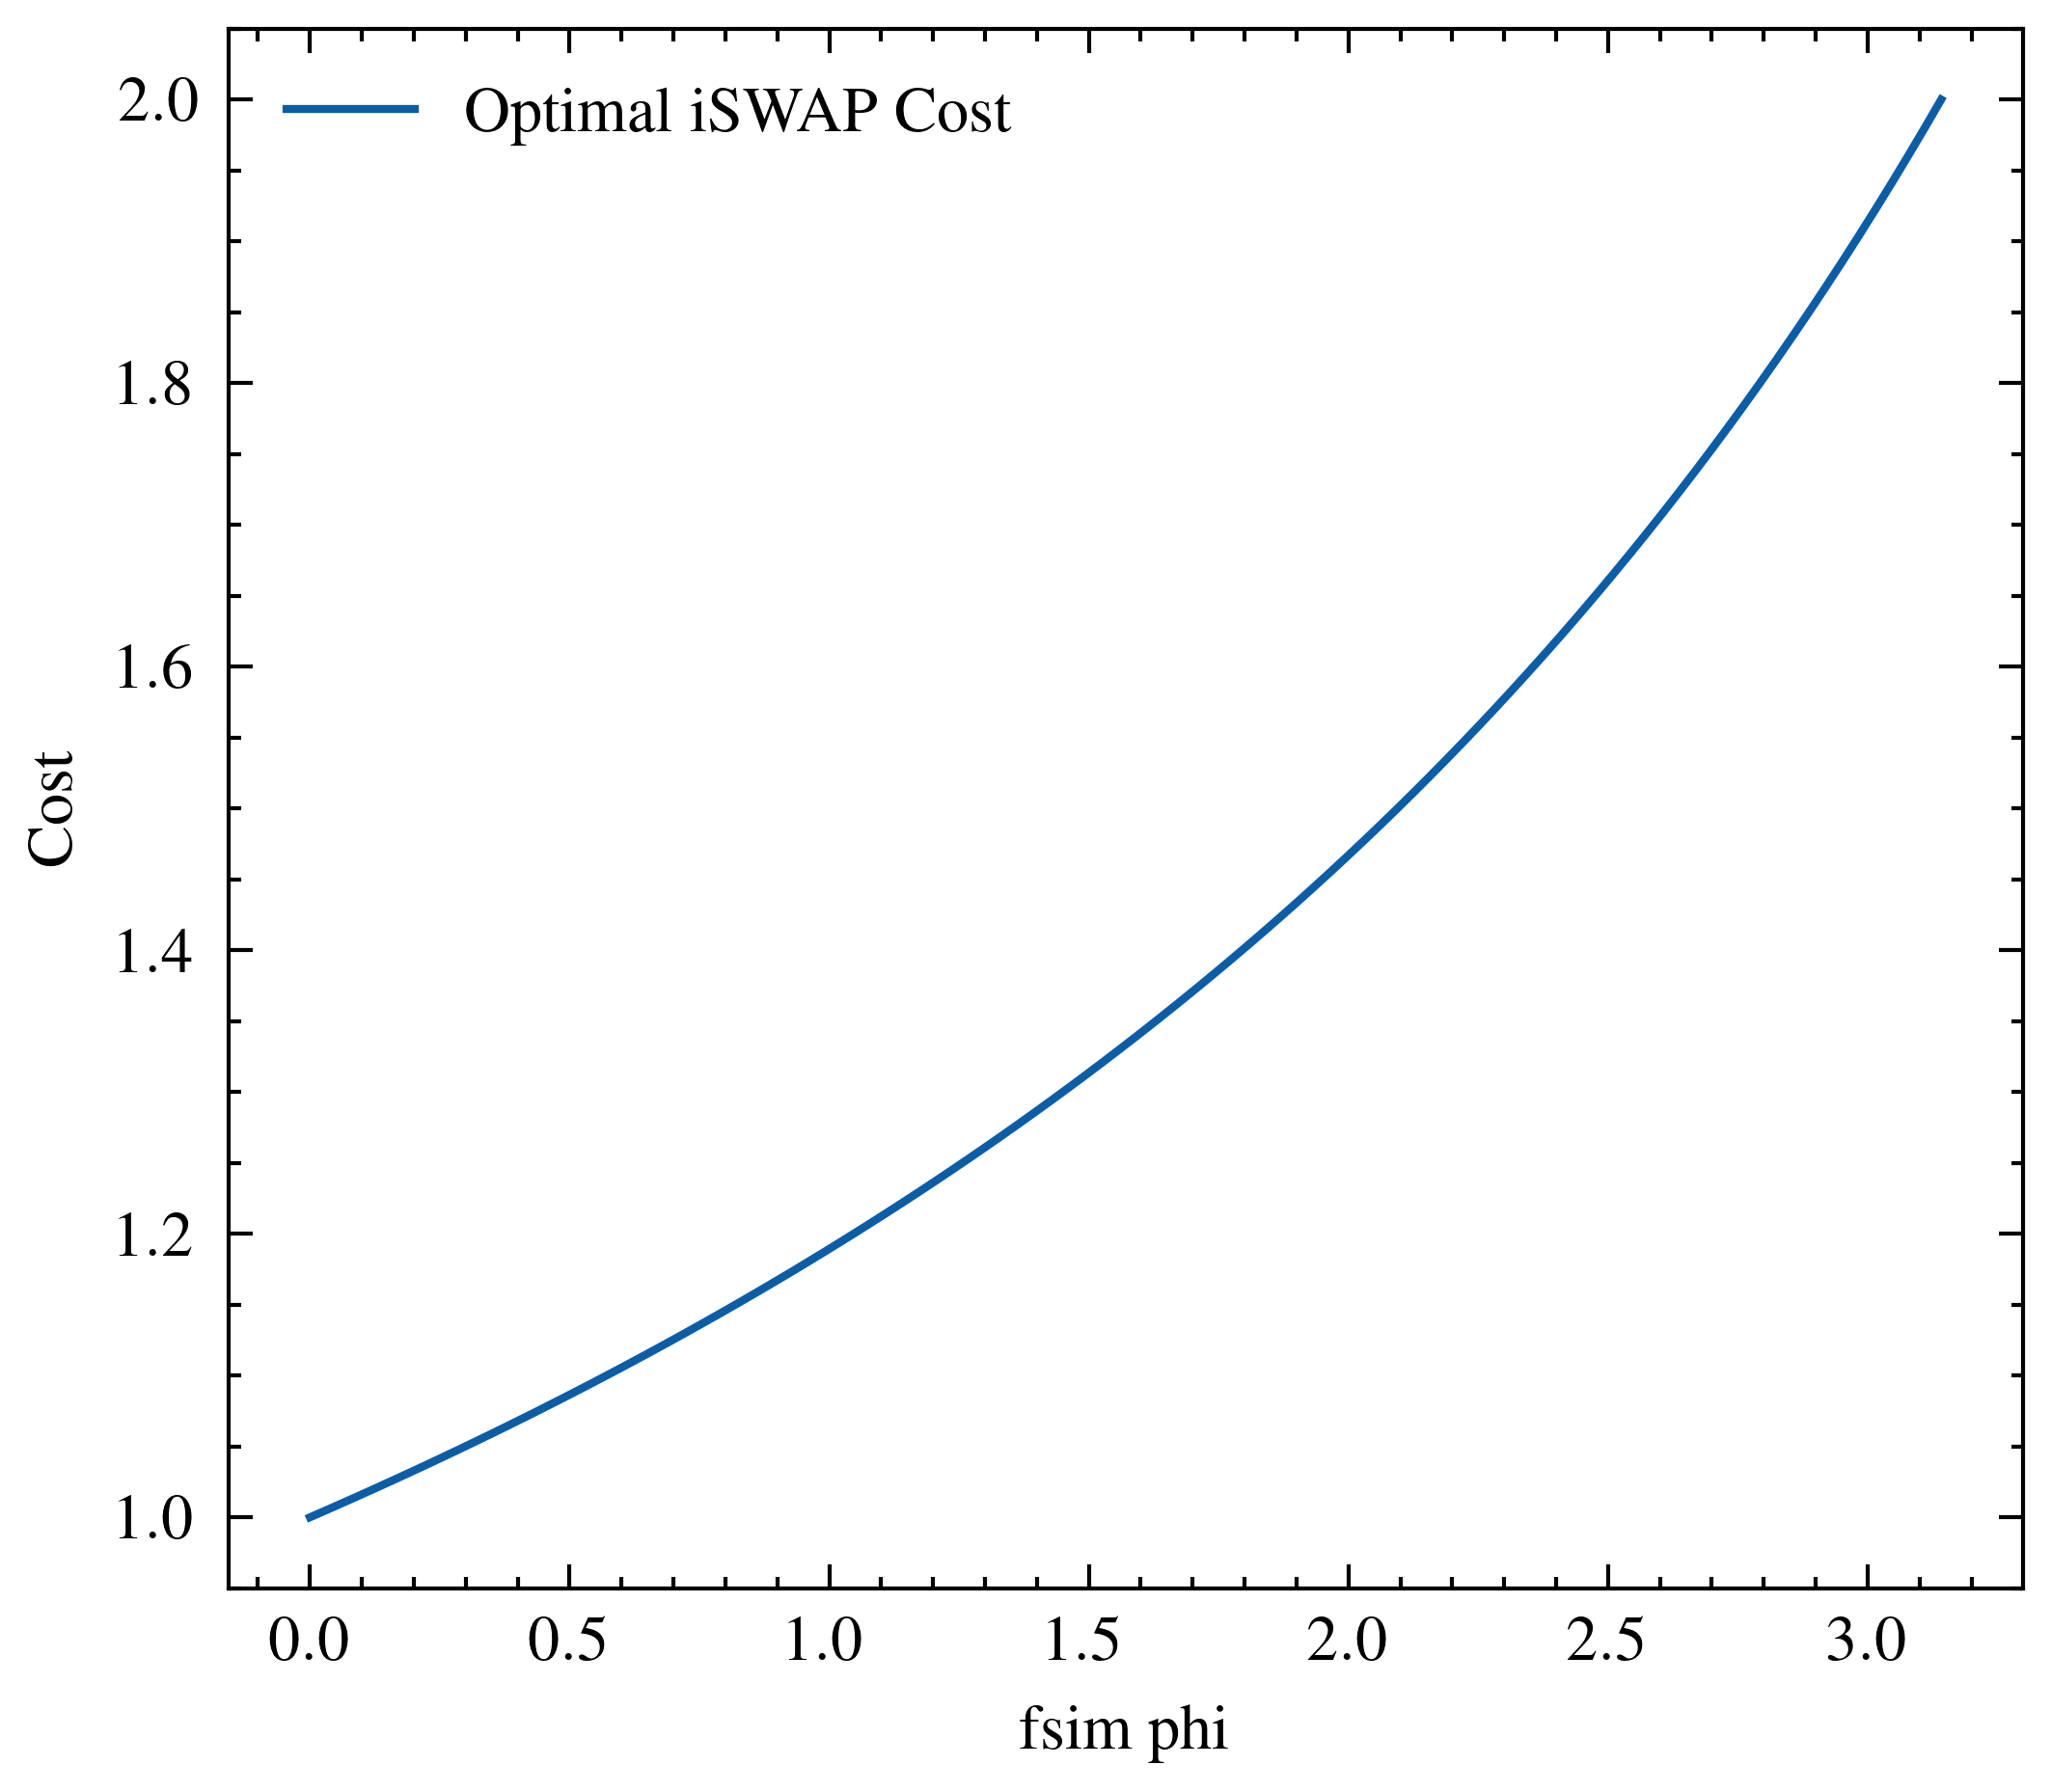

In [40]:
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axs = plt.subplots(1, 1, figsize=(4, 3.5), sharey=True)

    axs.plot(phi_values, optimal_costs, label="Optimal iSWAP Cost")
    axs.set_xlabel("fsim phi")
    axs.set_ylabel("Cost")
    axs.legend()

    plt.show()

this is a very contrived experiment, but can show cost of decomposing iSWAP as a function of fsim phi (the strength of the ZZ error) for different discrete fractional isas. Google said they tried to implement a iswap surface code using syc. They wouldn't use partial gates because it would break their implementation of virtual-z gates

Sweeping φ:   0%|          | 0/32 [00:00<?, ?it/s]

Sweeping φ: 100%|██████████| 32/32 [00:01<00:00, 19.06it/s]


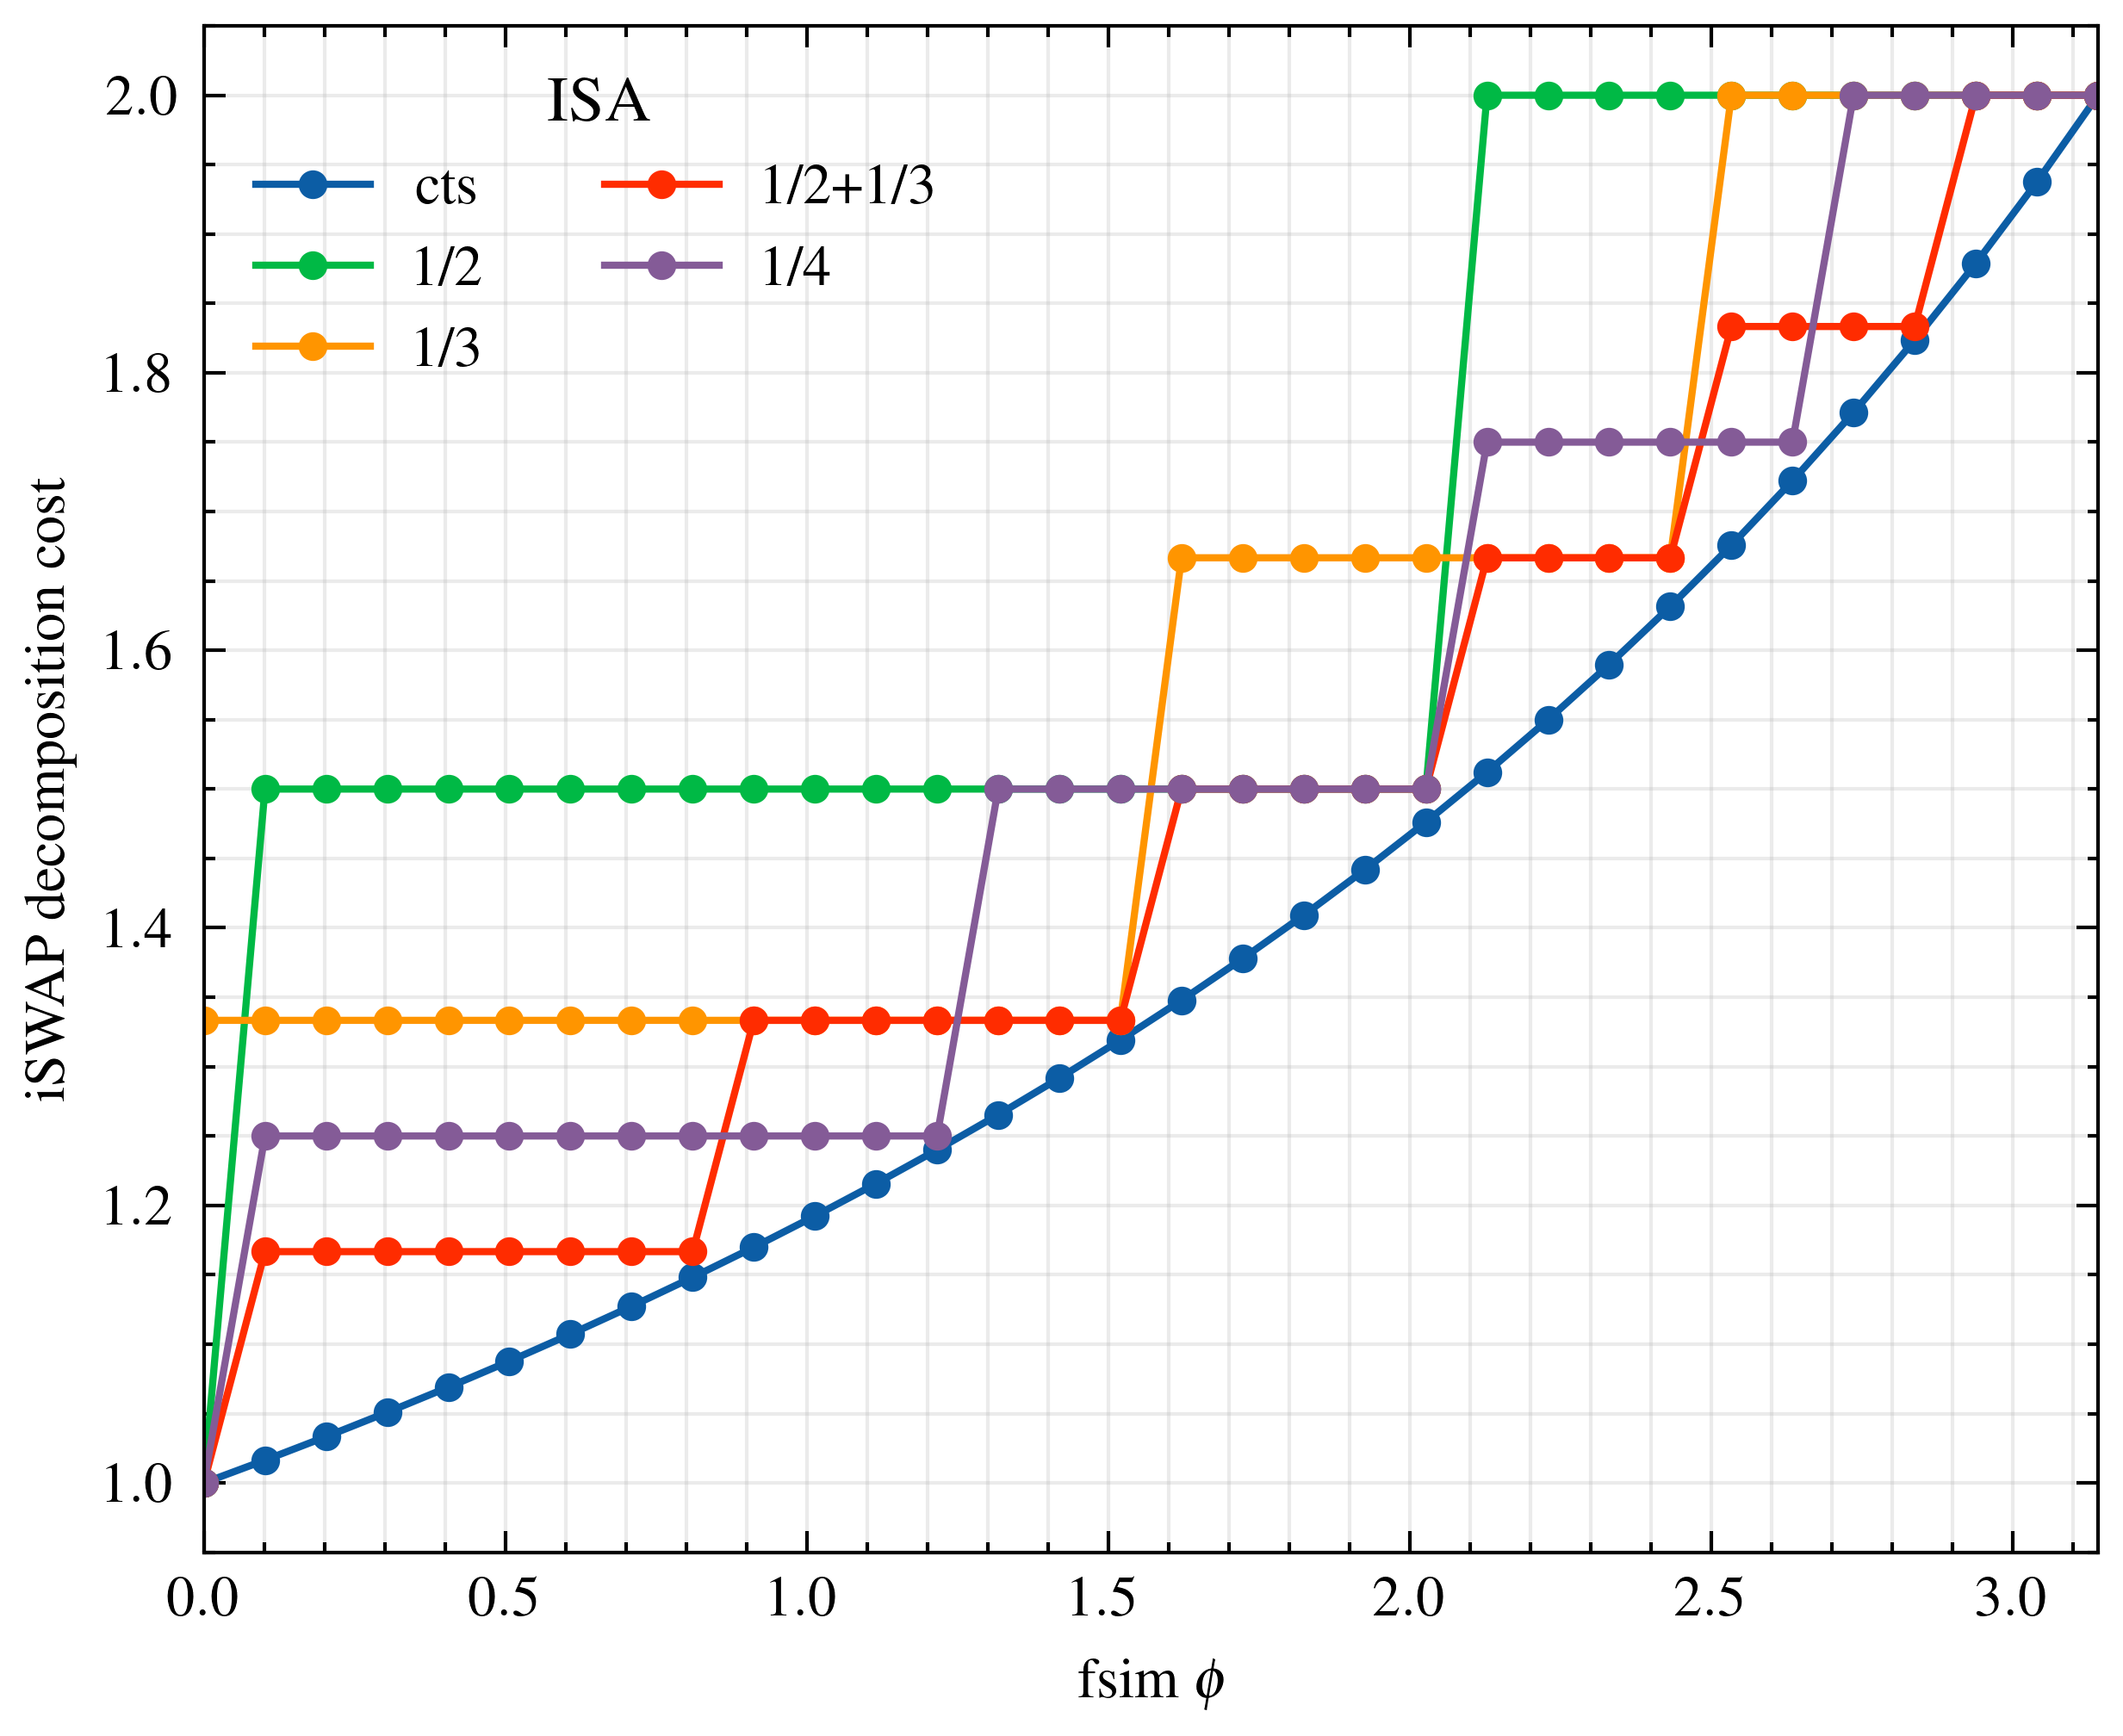

In [59]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import XXPlusYYGate, iSwapGate

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.cts_linear_program import ContinuousISAConstraints
from gulps.utils.invariants import GateInvariants


# ---------- primitives ----------
def fsim(theta, phi):
    qc = QuantumCircuit(2, name="fsim")
    qc.append(XXPlusYYGate(2 * theta), [0, 1])
    qc.cp(phi, 0, 1)
    return qc.to_gate()


target_inv = GateInvariants.from_unitary(iSwapGate())

ISA_SPECS = {
    "1/2": (0.5,),
    "1/3": (1 / 3,),
    "1/2+1/3": (0.5, 1 / 3),
    "1/4": (1 / 4,),
}
LABEL_ORDER = ["cts", "1/2", "1/3", "1/2+1/3", "1/4"]
MAX_SEQUENCE_LEN = 8  # for the CTS solver only


# ---------- evaluators ----------
def optimal_cost_continuous(phi: float) -> float:
    base = GateInvariants.from_unitary(fsim(np.pi / 2, phi).power(1.0))
    solver = ContinuousISAConstraints(
        base=base, sequence_length=MAX_SEQUENCE_LEN, offset=1e-6
    )
    solver.set_target(target_inv, rho_bool=False)
    _, _, ks = solver.solve(log_output=False)
    return float(np.sum(ks))


def best_discrete_cost(phi: float, fracs: tuple[float, ...]) -> float:
    base_gate = fsim(np.pi / 2, phi)
    isa = [
        (
            base_gate.power(fr),
            fr,
            (f"{int(fr)}" if fr >= 1 else f"{int(round(fr * 6))}/{6}"),
        )
        for fr in fracs
    ]
    gate_set, costs, names = zip(*isa)
    dec = GulpsDecomposer(
        gate_set=gate_set, costs=costs, names=names, precompute_polytopes=False
    )
    try:
        sentence_out, _ = dec._best_decomposition(target_inv=target_inv)
        if sentence_out is None:
            return np.nan
        return float(sum(dec.isa.cost_dict[g] for g in sentence_out))
    except Exception as e:
        print(f"Error occurred: {e}")
        return np.nan


# ---------- sweep ----------
phi_values = np.linspace(0.0, np.pi, 32)
series = {k: [] for k in LABEL_ORDER}

for phi in tqdm(phi_values, desc="Sweeping φ"):
    # optimal (continuous)
    series["cts"].append(optimal_cost_continuous(phi))
    # discrete
    for label in LABEL_ORDER:
        if label == "cts":
            continue
        series[label].append(best_discrete_cost(phi, ISA_SPECS[label]))

# ---------- plot ----------
with plt.style.context(["ieee", "use_mathtext", "science"]):
    fig, ax = plt.subplots(figsize=(4.25, 3.5))
    for label in LABEL_ORDER:
        ax.plot(phi_values, series[label], label=label, marker=".")
    ax.set_xlabel(r"$\mathrm{fsim}\ \phi$")
    ax.set_ylabel("iSWAP decomposition cost")
    ax.set_xlim(phi_values.min(), phi_values.max())
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(title="ISA", fontsize=8, title_fontsize=9, ncols=2)
    fig.tight_layout()
    plt.show()
